Saving Aggregated_results_20260709_094945.csv to Aggregated_results_20260709_094945 (1).csv


Saving results_20260709_094945.csv to results_20260709_094945 (1).csv
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


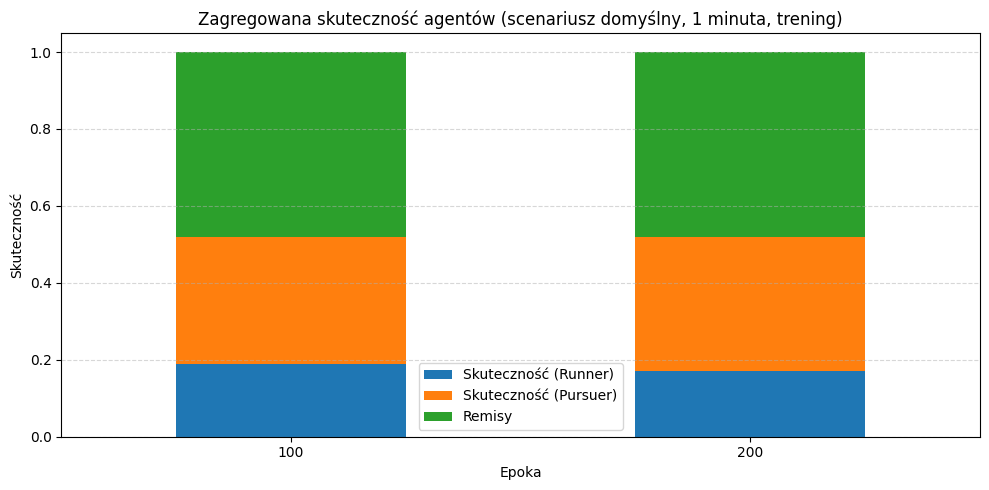

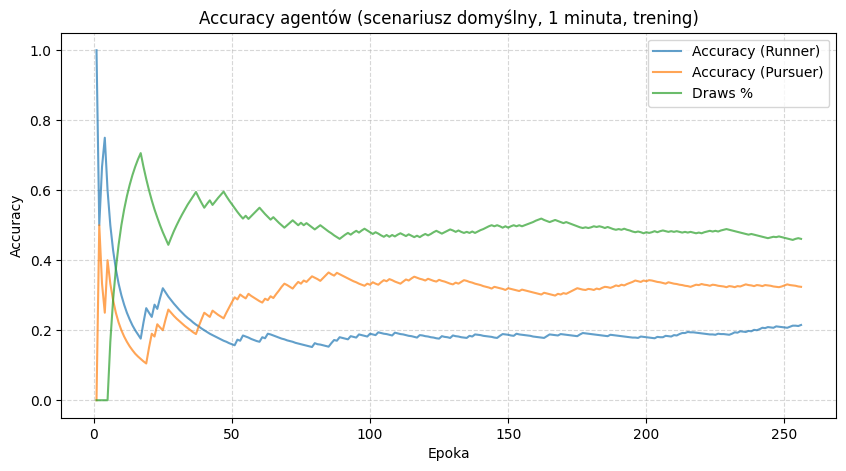

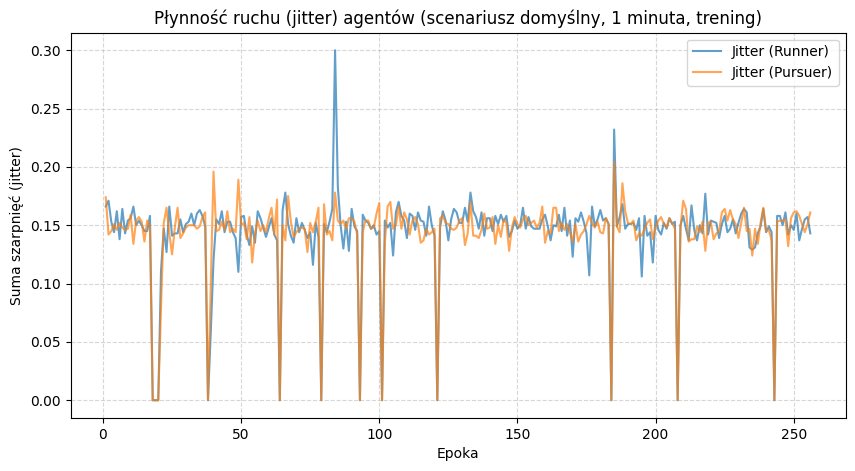

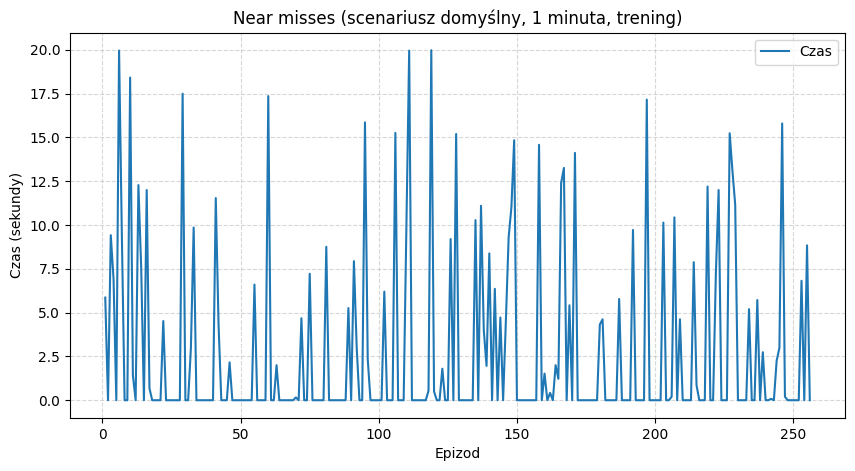

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import datetime
from google.colab import files
from IPython.display import display, HTML

def plot_aggregated_accuracy(csv_path, save_dir):
    df = pd.read_csv(csv_path)

    ax = df.plot(x='Episode', y=['RunnerAcc', 'PursuerAcc', 'DrawsPercentage'], kind='bar', stacked=True, figsize=(10, 5))

    plt.title('Zagregowana skuteczność agentów (scenariusz domyślny, 1 minuta, trening)')
    plt.xlabel('Epoka')
    plt.ylabel('Skuteczność')

    plt.legend(['Skuteczność (Runner)', 'Skuteczność (Pursuer)', 'Remisy'])

    plt.grid(True, linestyle='--', alpha=0.5, axis='y')

    plt.xticks(rotation=0)

    plt.tight_layout()

    save_path = os.path.join(save_dir, '1_Acc_agg.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

def plot_acc(csv_path, save_dir):
    df = pd.read_csv(csv_path)

    plt.figure(figsize=(10, 5))
    plt.plot(df['Episode'], df['RunnerAcc'], label='Accuracy (Runner)', alpha=0.7)
    plt.plot(df['Episode'], df['PursuerAcc'], label='Accuracy (Pursuer)', alpha=0.7)
    plt.plot(df['Episode'], df['DrawsPercentage'], label='Draws %', alpha=0.7)

    plt.title('Accuracy agentów (scenariusz domyślny, 1 minuta, trening)')
    plt.xlabel('Epoka')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    save_path = os.path.join(save_dir, '2_Accuracy.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()


def plot_jitter(csv_path, save_dir):
    df = pd.read_csv(csv_path)

    plt.figure(figsize=(10, 5))
    plt.plot(df['Episode'], df['RunnerJitter'], label='Jitter (Runner)', alpha=0.7)
    plt.plot(df['Episode'], df['PursuerJitter'], label='Jitter (Pursuer)', alpha=0.7)

    plt.title('Płynność ruchu (jitter) agentów (scenariusz domyślny, 1 minuta, trening)')
    plt.xlabel('Epoka')
    plt.ylabel('Suma szarpnięć (jitter)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    save_path = os.path.join(save_dir, '3_Jitter.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()


def plot_near_misses(csv_path, save_dir):
    df = pd.read_csv(csv_path)

    plt.figure(figsize=(10, 5))
    plt.plot(df['Episode'], df['NearMissTime'], label='Czas')

    plt.title('Near misses (scenariusz domyślny, 1 minuta, trening)')
    plt.xlabel('Epizod')
    plt.ylabel('Czas (sekundy)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    save_path = os.path.join(save_dir, '4_Near_Misses.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()


if __name__ == "__main__":
    display(HTML('<h3>Select Aggregated Results CSV</h3>'))
    uploaded_agg = files.upload()
    agg_results = list(uploaded_agg.keys())[0]

    display(HTML('<br><h3>Select Raw Results CSV</h3>'))
    uploaded_raw = files.upload()
    results = list(uploaded_raw.keys())[0]

    try:
        from google.colab import drive
        drive.mount('/content/drive')

        base_dir = '/content/drive/MyDrive/Magisterka_wykresy'
    except ImportError:
        print("Google Drive not mounted. Files will be saved locally.")
        base_dir = 'Magisterka_wykresy'

    try:
        timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        folder_name = os.path.join(base_dir, f"results_{timestamp}")

        os.makedirs(folder_name, exist_ok=True)

        plot_aggregated_accuracy(agg_results, folder_name)
        plot_acc(results, folder_name)
        plot_jitter(results, folder_name)
        plot_near_misses(results, folder_name)
    except FileNotFoundError as e:
        print(f"Error: file not found. Details: {e}")